In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
my_cols = ["red", "darkorange", "gold", "limegreen","dodgerblue", "deeppink", "darkviolet"]

In [45]:
def clean_data(df, failed_image_names):
    # df= df[df["flag"]!="IMAGE FAILED"]
    # build combined key
    combined = df["lif_name"].astype(str) + "_" + df["image_name"].astype(str)
    # keep only rows NOT in failed_image_names
    df = df[~combined.isin(failed_image_names)]    
    def helper(row):
        lif_name = str(row['lif_name']).lower()
        image_name = str(row['image_name']).lower()
        if "untreat" in image_name:
            row["treatment"] = "Untreated"
        if "triton" in image_name:
            row["treatment"] = "Triton"
        if "vpa" in image_name:
            row["treatment"] = "VPA"

        return row
    df =  df.apply(helper, axis=1)
    # first = ["milestone", "date", "sample", "device", "position" ,"p_cm/s", "p_um/s", "condition"]

    # df = df[first + [c for c in df.columns if c not in first]]
    return df

In [36]:
folder = Path(r"./maria_outputs")
csv_files = list(folder.glob("*.csv"))
print(len(csv_files))


8


In [37]:
all_csvs = []
for csv_file in csv_files:
    csv = pd.read_csv(csv_file)
    all_csvs.append(csv)
    

In [67]:
all_data = pd.concat(all_csvs)
failed_image_names = [""]
all_data=clean_data(all_data, failed_image_names)
all_data.to_csv("maria_combined_data.csv", index=False)

In [42]:
all_data.columns

Index(['lif_name', 'image_name', 'treatment', 'timepoint', 't0_t3_p',
       'lif_path', 'image_index', 'image_shape', 'n_planes_found',
       'n_planes_kept', 'kept_z_min', 'kept_z_max',
       'maternal_region_volume_px', 'fetal_region_volume_px',
       'maternal_initial_intensity', 'fetal_initial_intensity',
       'maternal_final_intensity', 'fetal_final_intensity',
       'bleaching_coefficient_t0_t1', 'bleaching_coefficient_t1_t2',
       'bleaching_coefficient_t2_t3', 'bleaching_coefficient_t0_t3', 't0_t1_p',
       't1_t2_p', 't2_t3_p', 't0_t1_pct_change', 't1_t2_pct_change',
       't2_t3_pct_change', 'maternal_um3', 'fetal_um3', 'interface_um2',
       'x_um', 'z_um', 'failed_geometry', 'failed_hump', 'hump_zs', 'error',
       'position'],
      dtype='object')

In [63]:
test = all_data[all_data["treatment"]!= "unknown"]
print(test.shape)
test = test[test["failed_hump"]==False & (test["failed_geometry"]==False)]
print(test.shape)

(211, 38)
(195, 38)


In [66]:
test[test["timepoint"]=="unknown"]

,lif_name,image_name,treatment,timepoint,t0_t3_p,lif_path,image_index,image_shape,n_planes_found,n_planes_kept,...,maternal_um3,fetal_um3,interface_um2,x_um,z_um,failed_geometry,failed_hump,hump_zs,error,position
8,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device1/P 1,VPA,unknown,1.092871e-05,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,8,"(4, 3, 13, 512, 512)",11.0,11.0,...,2.968413e+07,1.195565e+08,191284.434854,2.274951,10.000242,False,False,[],NaN,p1
9,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device1/P 2,VPA,unknown,1.674385e-05,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,9,"(4, 3, 16, 512, 512)",6.0,5.0,...,7.930201e+06,5.990646e+07,79342.650221,2.274951,10.000240,False,False,[],NaN,p2
10,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device2/P 1,VPA,unknown,8.538761e-05,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,10,"(4, 3, 15, 512, 512)",13.0,3.0,...,5.635214e+06,3.506677e+07,83975.572906,2.274951,10.000236,False,False,[],NaN,p1
11,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device2/P 2,VPA,unknown,-4.444848e-05,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,11,"(4, 3, 16, 512, 512)",15.0,10.0,...,7.991220e+06,1.276821e+08,186146.369575,2.274951,10.000240,False,False,[],NaN,p2
12,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device3/P 1,VPA,unknown,2.507054e-04,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,12,"(4, 3, 24, 512, 512)",23.0,21.0,...,3.373273e+07,2.511812e+08,437423.277105,2.274951,10.000239,False,False,[],NaN,p1
13,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device3/P 2,VPA,unknown,3.405807e-04,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,13,"(4, 3, 24, 512, 512)",24.0,20.0,...,3.323826e+07,2.381084e+08,363076.016898,2.274951,10.000239,False,False,[],NaN,p2
14,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device4/P 1,VPA,unknown,6.933170e-06,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,14,"(4, 3, 23, 512, 512)",20.0,14.0,...,4.626707e+07,1.572428e+08,308963.351840,2.274951,10.000236,False,False,[],NaN,p1
15,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device4/P 2,VPA,unknown,6.425370e-06,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,15,"(4, 3, 23, 512, 512)",18.0,15.0,...,4.181198e+07,1.616979e+08,299348.148820,2.274951,10.000236,False,False,[],NaN,p2
16,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device5/P 1,VPA,unknown,1.092806e-05,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,16,"(4, 3, 25, 512, 512)",21.0,16.0,...,4.907267e+07,1.679943e+08,326129.221698,2.274951,9.999762,False,False,[],NaN,p1
17,Exp2_Valproic-Acid_20251114.lif,VPA_500ugml_Device5/P 2,VPA,unknown,1.269877e-05,Z:\Maria Cuende\0_Projects\0_Placenta\Barrier ...,17,"(4, 3, 26, 512, 512)",26.0,1.0,...,2.691377e+06,1.087596e+07,21612.553914,2.274951,10.000240,False,False,[],NaN,p2


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_1259408\3543962811.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=test.reset_index(), x="treatment", y="t0_t3_p", ax=ax, palette=my_cols)


(0.0, 0.0001)

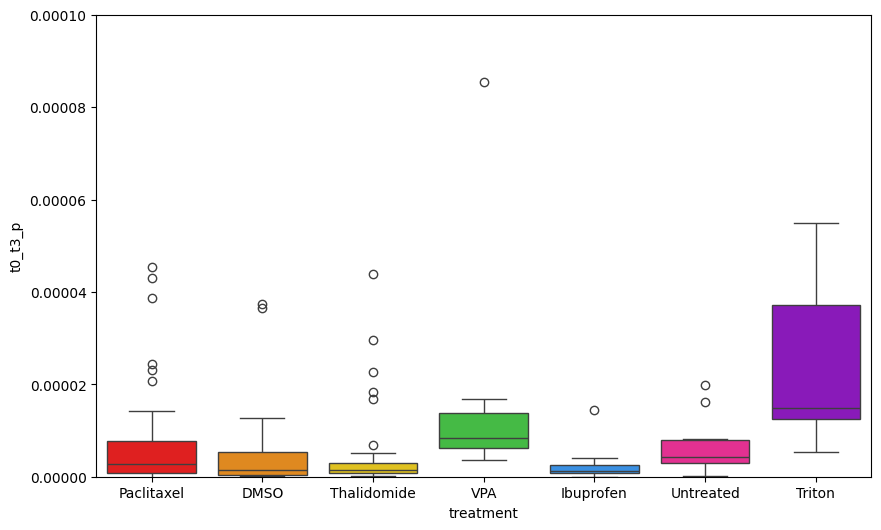

In [64]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=test.reset_index(), x="treatment", y="t0_t3_p", ax=ax, palette=my_cols)
ax.set_ylim(0,0.0001)

In [76]:
all_data.to_csv("./outputs/combined_outputs.csv")


Text(0.5, 0, 'Permeability cm/s')

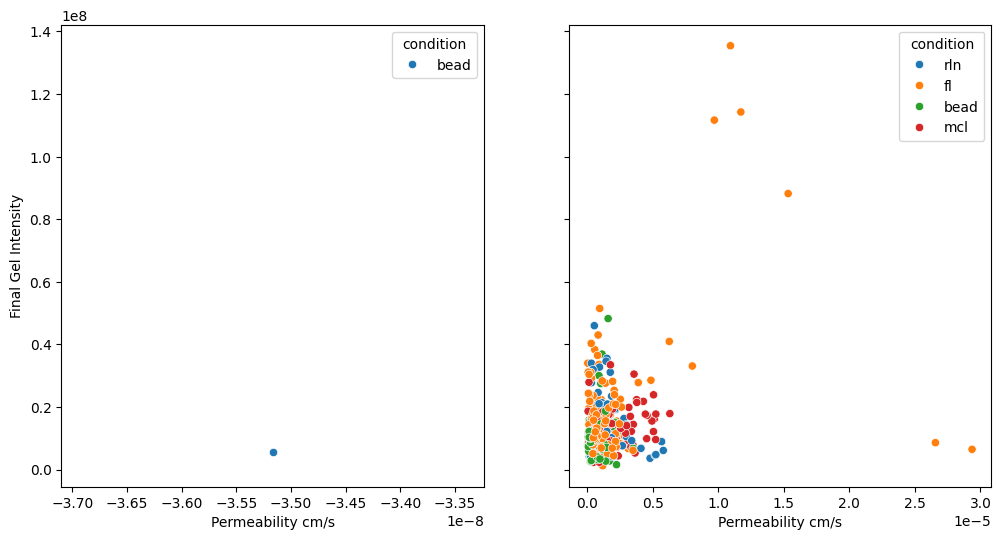

In [26]:
m4 = all_data[all_data["milestone"]=="m4"]
m4 = m4[m4["condition"]!="unknown"]
neg_data = m4[m4["p_cm/s"]<0]
pos_data = m4[m4["p_cm/s"]>=0]
fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)
sns.scatterplot(data=neg_data, y="final_gel_intensity", x="p_cm/s",  ax=ax[0], hue = "condition")
sns.scatterplot(data=pos_data, y="final_gel_intensity", x="p_cm/s", ax=ax[1],  hue = "condition")
ax[0].set_ylabel("Final Gel Intensity")
ax[0].set_xlabel("Permeability cm/s")
ax[1].set_xlabel("Permeability cm/s")

Text(0.5, 0, 'Permeability cm/s')

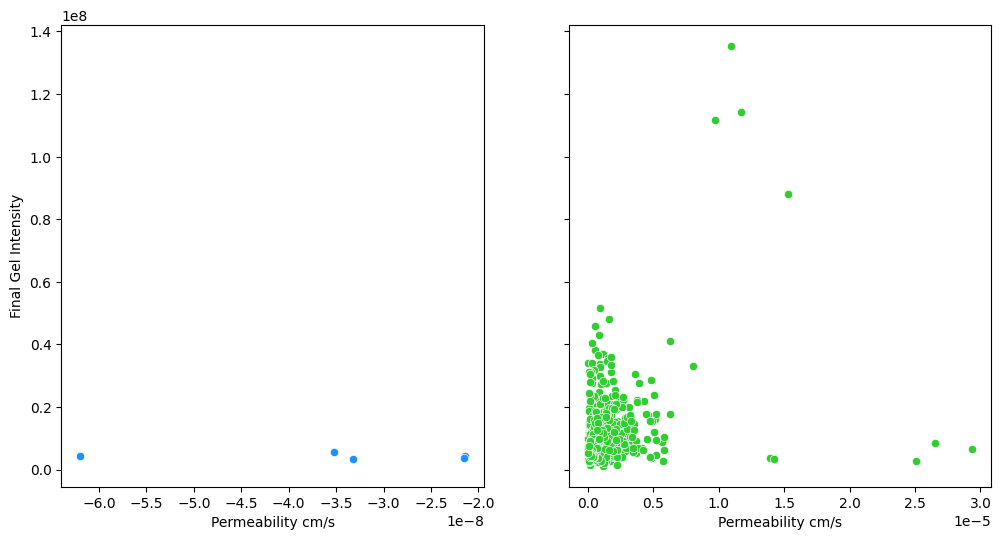

In [ ]:
neg_data = all_data[all_data["p_cm/s"]<0]
pos_data = all_data[all_data["p_cm/s"]>=0]
fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)
sns.scatterplot(data=neg_data, y="final_gel_intensity", x="p_cm/s",  ax=ax[0], color="dodgerblue")
sns.scatterplot(data=pos_data, y="final_gel_intensity", x="p_cm/s", ax=ax[1], color="limegreen")
ax[0].set_ylabel("Final Gel Intensity")
ax[0].set_xlabel("Permeability cm/s")
ax[1].set_xlabel("Permeability cm/s")

In [78]:
all_data.head()

,milestone,date,sample,device,position,p_cm/s,p_um/s,condition,lif_name,image_name,image_shape,final_gel_intensity,final_vascular_intensity,initial_gel_intensity,initial_vascular_intensity,vascular_volume_um3,gel_volume_um3,vasculature_surface_area_um2,bleaching_coefficient,ligand
0,m4,2024.10.24,rln2,device1,p2,3.445425e-07,0.003445,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 2,"(3, 36, 512, 512)",15246285.0,116276721.0,11906772.0,124558040.0,7.342314e+07,1.704046e+08,5.396960e+06,1.071221,unknown
1,m4,2024.10.24,rln2,device1,p1,3.821311e-07,0.003821,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 1,"(3, 42, 512, 512)",17222645.0,88108795.0,14422564.0,91270589.0,7.262491e+07,2.113264e+08,6.832713e+06,1.035885,unknown
2,m4,2024.10.24,rln2,device1,p4,2.036221e-07,0.002036,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 4,"(3, 41, 512, 512)",15005195.0,114410632.0,13182857.0,119022366.0,7.678528e+07,2.009932e+08,6.287928e+06,1.040309,unknown
3,m4,2024.10.24,rln2,device1,p3,8.590670e-08,0.000859,rln,m4_2024.10.24_fl2_fl6,rLN2_24.10.24_device1/P 3,"(3, 42, 512, 512)",18832157.0,134287948.0,18135117.0,139589283.0,9.163753e+07,1.923138e+08,7.375254e+06,1.039477,unknown
5,m4,2024.10.24,fl2,device1,p1,9.586856e-07,0.009587,fl,m4_2024.10.24_fl2_fl6,FL2_24.10.24_device1/P 1,"(3, 39, 512, 512)",51458024.0,115178690.0,31348719.0,110135419.0,9.560956e+07,1.698232e+08,1.115201e+07,0.956214,unknown


In [79]:
OUT_DIR = Path("./outputs./subsets")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# tweak these thresholds
COEFFVAR_FLAG_THRESHOLD = 0.30   # coefficient of variation (std/mean)
STD_FLAG_THRESHOLD = None  # or set e.g. 0.5 to flag by absolute std instead

for date in all_data["date"].unique():
    for milestone in all_data.loc[all_data["date"] == date, "milestone"].unique():

        subset = all_data[
            (all_data["date"] == date) &
            (all_data["milestone"] == milestone)
        ][["sample", "device", "position", "p_cm/s"]].copy()

        # Ensure numeric
        subset["p_cm/s"] = pd.to_numeric(subset["p_cm/s"], errors="coerce")

        # --- summary: average over positions within (condition, device) ---
        summary = (
            subset
            .groupby(["sample", "device"], as_index=False)
            .agg(
                n_positions=("p_cm/s", "count"),
                mean_p=("p_cm/s", "mean"),
                std_p=("p_cm/s", "std"),
            )
        )

        # coefficient of variation (guard against divide-by-zero)
        summary["cv_p"] = summary["std_p"] / summary["mean_p"].replace(0, np.nan)

        # flag high variance
        if STD_FLAG_THRESHOLD is not None:
            summary["high_variance_flag"] = summary["std_p"] > STD_FLAG_THRESHOLD
        else:
            summary["high_variance_flag"] = summary["cv_p"] > COEFFVAR_FLAG_THRESHOLD

        # optional: nicer column name
        summary = summary.rename(columns={"mean_p": "avg_p_cm/s"})

        # --- write one CSV with raw + summary appended ---
        safe_date = str(date).replace("/", "-").replace(":", "-").replace(" ", "_")
        safe_milestone = str(milestone).replace("/", "-").replace(":", "-").replace(" ", "_")
        out_path = OUT_DIR / f"{safe_date}__{safe_milestone}.csv"

        with open(out_path, "w", newline="") as f:
            f.write(f"# date={date}, milestone={milestone}\n")
            f.write("# raw_rows\n")
            subset.to_csv(f, index=False)

            f.write("\n")
            f.write("# summary_by_condition_device\n")
            summary.to_csv(f, index=False)

        print("Saved:", out_path)


Saved: outputs.\subsets\2024.10.24__m4.csv
Saved: outputs.\subsets\2024.11.14__m4.csv
Saved: outputs.\subsets\2024.12.04__m4.csv
Saved: outputs.\subsets\2025.02.05__m4.csv
Saved: outputs.\subsets\2025.02.27__m4.csv
Saved: outputs.\subsets\2025.03.20__m4.csv
Saved: outputs.\subsets\2025.06.27__m4.csv
Saved: outputs.\subsets\2025.10.02__m7.csv
Saved: outputs.\subsets\2025.10.22__m7.csv
Saved: outputs.\subsets\2025.11.12__m7.csv
Saved: outputs.\subsets\2025.12.04__m7.csv
